# LSTM Classifier


In [9]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

sys.path.append('..')
from src.data_utils import stratified_split, build_label_maps, encode_labels, build_vocab, encode_texts, make_dataloaders_from_arrays
from src.train_utils import set_seed, run_training, evaluate, compute_metrics
from src.pytorch_models import select_device

set_seed(2026)
device = select_device()
print('Device:', device)

CLASS_ORDER = ['Human', 'Google', 'Meta', 'OpenAI', 'Anthropic']

# Hiperparâmetros 
TRAIN_FRACTION = 0.5        # base: 0.1
MAX_VOCAB  = 20000
MAX_LEN    = 120
MIN_FREQ   = 3
EMBED_DIM  = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT    = 0.3
BATCH_SIZE = 256
LR         = 1e-3
EPOCHS     = 30
PATIENCE   = 5

Device: mps


## Dados

In [10]:
df = pd.read_csv('../data/dataset_final.csv')
train_df, val_df = stratified_split(df, 'text', 'label', test_size=0.2, seed=2026)

if TRAIN_FRACTION < 1.0:
    train_df = train_df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(frac=TRAIN_FRACTION, random_state=2026)
    ).reset_index(drop=True)

#test_df = pd.read_csv('../../../dataset-exemplos.csv', sep=';')
test_df = pd.read_csv('../data/subm1_labels_revealed.csv', sep=';')
test_df = test_df.rename(columns={'Text': 'text', 'Label': 'label'})

print(f'Treino: {len(train_df):,} | Validação: {len(val_df):,} | Teste (prof): {len(test_df)}')

label_to_idx, idx_to_label = build_label_maps(CLASS_ORDER)
y_train = encode_labels(train_df['label'], label_to_idx)
y_val   = encode_labels(val_df['label'],   label_to_idx)
y_test  = encode_labels(test_df['label'],  label_to_idx)

vocab = build_vocab(train_df['text'], max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
print(f'Vocab size: {len(vocab):,}')

X_train = encode_texts(train_df['text'], vocab, MAX_LEN)
X_val   = encode_texts(val_df['text'],   vocab, MAX_LEN)
X_test  = encode_texts(test_df['text'],  vocab, MAX_LEN)

train_loader, val_loader = make_dataloaders_from_arrays(X_train, y_train, X_val, y_val, BATCH_SIZE)
test_loader, _           = make_dataloaders_from_arrays(X_test,  y_test,  X_test, y_test, BATCH_SIZE)

/var/folders/z5/2mxsb3js3kz6dz3tqdwhwnf40000gn/T/ipykernel_62076/728685750.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = train_df.groupby('label', group_keys=False).apply(


Treino: 120,000 | Validação: 60,000 | Teste (prof): 100
Vocab size: 20,000


## Modelo

In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        
        embedded = self.embedding(x)    # x: (batch_size, seq_len)
        _, (hidden, cell) = self.lstm(embedded)
        
        # hidden: (num_layers, batch_size, hidden_dim)
        last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        return self.fc(out)


model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(CLASS_ORDER),
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nParâmetros totais: {total_params:,}')

LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)

Parâmetros totais: 2,692,741


## Treino

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

mlflow_params = {
    'model': 'LSTM',
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'embed_dim': EMBED_DIM,
    'dropout': DROPOUT,
    'lr': LR,
    'batch_size': BATCH_SIZE,
    'train_fraction': TRAIN_FRACTION,
    'max_vocab': MAX_VOCAB,
    'max_len': MAX_LEN,
}

history, best_state, best_epoch = run_training(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=EPOCHS, patience=PATIENCE, verbose=True,
    mlflow_params=mlflow_params,
)

model.load_state_dict(best_state)
print(f'\nMelhor epoch: {best_epoch}')


Epoch 01/30 | train_loss=1.3486 train_acc=0.3736 | val_loss=1.0296 val_acc=0.5178
Epoch 02/30 | train_loss=0.8295 train_acc=0.6204 | val_loss=0.6820 val_acc=0.6845
Epoch 03/30 | train_loss=0.5837 train_acc=0.7336 | val_loss=0.5162 val_acc=0.7993
Epoch 04/30 | train_loss=0.3892 train_acc=0.8570 | val_loss=0.3703 val_acc=0.8668
Epoch 05/30 | train_loss=0.2741 train_acc=0.9035 | val_loss=0.3321 val_acc=0.8884
Epoch 06/30 | train_loss=0.2068 train_acc=0.9303 | val_loss=0.3357 val_acc=0.8934
Epoch 07/30 | train_loss=0.1646 train_acc=0.9457 | val_loss=0.3016 val_acc=0.9029
Epoch 08/30 | train_loss=0.1310 train_acc=0.9578 | val_loss=0.3399 val_acc=0.9002
Epoch 09/30 | train_loss=0.1011 train_acc=0.9684 | val_loss=0.3408 val_acc=0.9053
Epoch 10/30 | train_loss=0.0842 train_acc=0.9739 | val_loss=0.3230 val_acc=0.9025
Epoch 11/30 | train_loss=0.0741 train_acc=0.9777 | val_loss=0.3664 val_acc=0.9009
Epoch 12/30 | train_loss=0.0638 train_acc=0.9808 | val_loss=0.3938 val_acc=0.9052
Epoch 13/30 | tr

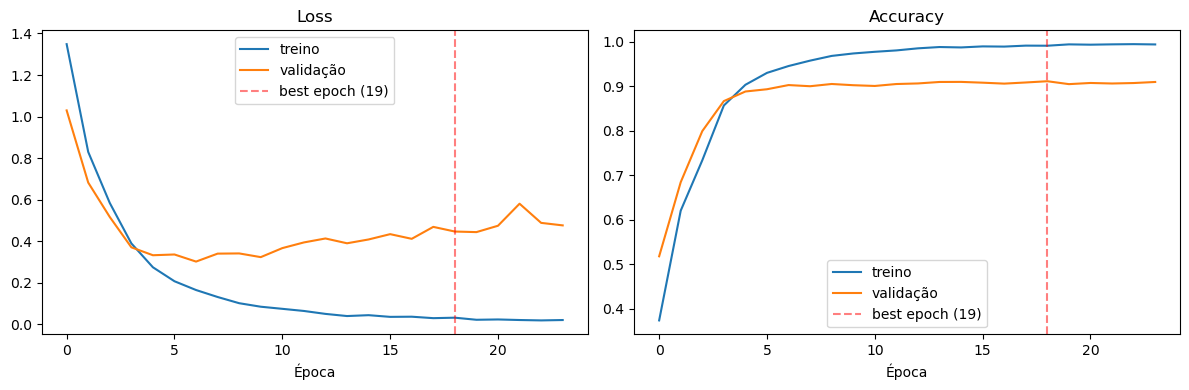

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (tr, vl, title) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_acc',  'val_acc',  'Accuracy'),
]):
    ax.plot(history[tr], label='treino')
    ax.plot(history[vl], label='validação')
    ax.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('Época')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Avaliação

In [14]:
for loader, name in [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]:
    _, _, y_true, y_pred = evaluate(model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(len(CLASS_ORDER))))
    print(f'\n=== {name} ===')
    print(f'Accuracy: {m["accuracy"]:.4f} | Macro F1: {m["macro_f1"]:.4f}')
    print(m['report'])


=== Validação (20%) ===
Accuracy: 0.9115 | Macro F1: 0.9114
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     12000
           1       0.92      0.89      0.90     12000
           2       0.90      0.90      0.90     12000
           3       0.89      0.89      0.89     12000
           4       0.95      0.94      0.94     12000

    accuracy                           0.91     60000
   macro avg       0.91      0.91      0.91     60000
weighted avg       0.91      0.91      0.91     60000


=== Teste (prof) ===
Accuracy: 0.4600 | Macro F1: 0.3678
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        34
           1       0.33      0.12      0.17        17
           2       0.50      0.11      0.18        18
           3       0.17      0.29      0.22        14
           4       0.31      0.71      0.43        17

    accuracy                           0.46       100
   macro avg

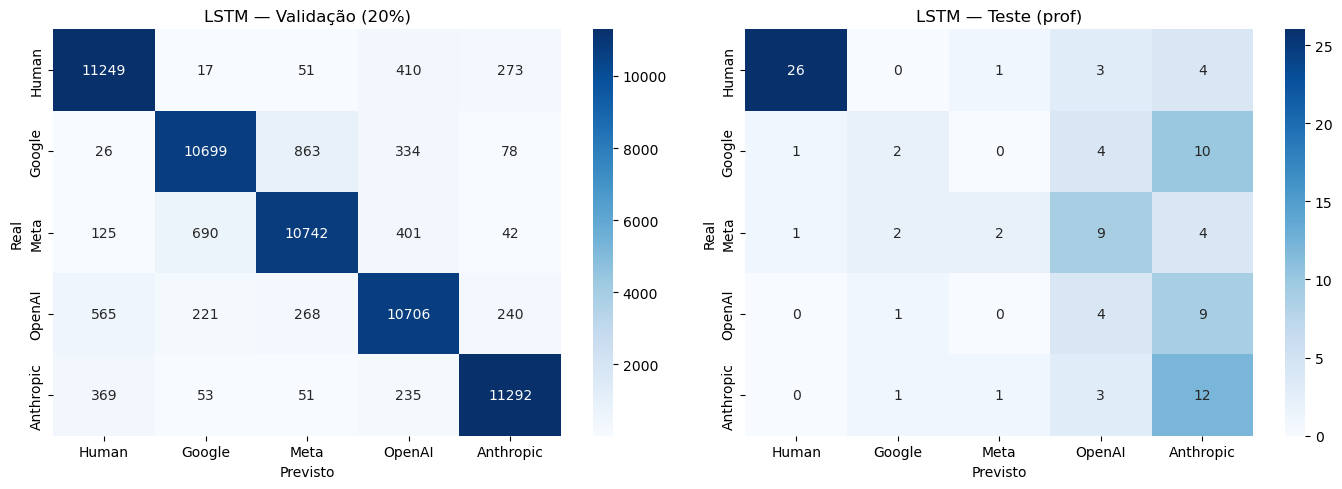

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (loader, name) in zip(axes, [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]):
    _, _, y_true, y_pred = evaluate(model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(len(CLASS_ORDER))))
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_title(f'LSTM — {name}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

## Guardar

In [16]:
import os, pickle
os.makedirs('../modelos', exist_ok=True)

torch.save({
    'state_dict': best_state,
    'vocab': vocab,
    'max_len': MAX_LEN,
    'class_order': CLASS_ORDER,
    'label_to_idx': label_to_idx,
    'config': {
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
    }
}, '../modelos/lstm.pt')
print('Guardado em ../modelos/lstm.pt')

Guardado em ../modelos/lstm.pt
